<a href="https://colab.research.google.com/github/Tanish-ops7710/DAFA1/blob/main/FA2Q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!wget -O /content/cs-training.csv \
"https://github.com/Dzidefo123/credit_risk_pred/raw/refs/heads/main/cs-training.csv"

import pandas as pd

df = pd.read_csv('/content/cs-training.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

--2026-08-18 20:00:07--  https://github.com/Dzidefo123/credit_risk_pred/raw/refs/heads/main/cs-training.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dzidefo123/credit_risk_pred/refs/heads/main/cs-training.csv [following]
--2026-08-18 20:00:08--  https://raw.githubusercontent.com/Dzidefo123/credit_risk_pred/refs/heads/main/cs-training.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7414964 (7.1M) [text/plain]
Saving to: ‘/content/cs-training.csv’

/content/cs-trainin 100%[===================>]   7.07M  --.-KB/s    in 0.05s   

2026-08-18 20:00:09 (134 MB/s) - ‘/content/cs-training.csv’

In [5]:
# ==========================================
# Q4 - STEP 1
# CLEANING + INFERENTIAL STATISTICS
# ==========================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency

# Remove unnecessary ID column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Fill missing values
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(
    df['MonthlyIncome'].median()
)

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(
    df['NumberOfDependents'].median()
)

print("Dataset shape after preprocessing:", df.shape)

# ==========================================
# 1. T-TEST: MONTHLY INCOME
# ==========================================

defaulted_income = df[
    df['SeriousDlqin2yrs'] == 1
]['MonthlyIncome']

non_defaulted_income = df[
    df['SeriousDlqin2yrs'] == 0
]['MonthlyIncome']

t_income, p_income = ttest_ind(
    defaulted_income,
    non_defaulted_income,
    equal_var=False
)

print("\n" + "="*60)
print("T-TEST: MONTHLY INCOME")
print("="*60)

print("Defaulted Mean:", round(defaulted_income.mean(), 2))
print("Non-defaulted Mean:", round(non_defaulted_income.mean(), 2))
print("T-Statistic:", round(t_income, 4))
print("P-Value:", p_income)

# ==========================================
# 2. T-TEST: DEBT RATIO
# ==========================================

defaulted_debt = df[
    df['SeriousDlqin2yrs'] == 1
]['DebtRatio']

non_defaulted_debt = df[
    df['SeriousDlqin2yrs'] == 0
]['DebtRatio']

t_debt, p_debt = ttest_ind(
    defaulted_debt,
    non_defaulted_debt,
    equal_var=False
)

print("\n" + "="*60)
print("T-TEST: DEBT RATIO")
print("="*60)

print("Defaulted Mean:", round(defaulted_debt.mean(), 4))
print("Non-defaulted Mean:", round(non_defaulted_debt.mean(), 4))
print("T-Statistic:", round(t_debt, 4))
print("P-Value:", p_debt)

# ==========================================
# 3. CHI-SQUARE: AGE GROUP VS DEFAULT
# ==========================================

df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['<=30', '31-40', '41-50', '51-60', '60+']
)

contingency = pd.crosstab(
    df['AgeGroup'],
    df['SeriousDlqin2yrs']
)

chi2, p_chi, dof, expected = chi2_contingency(
    contingency
)

print("\n" + "="*60)
print("CHI-SQUARE: AGE GROUP VS DEFAULT")
print("="*60)

print("\nContingency Table:")
print(contingency)

print("\nChi-Square Statistic:", round(chi2, 4))
print("P-Value:", p_chi)
print("Degrees of Freedom:", dof)

# ==========================================
# SIGNIFICANCE INTERPRETATION
# ==========================================

alpha = 0.05

print("\n" + "="*60)
print("STATISTICAL INTERPRETATION")
print("="*60)

print(
    "MonthlyIncome:",
    "Significant" if p_income < alpha else "Not Significant"
)

print(
    "DebtRatio:",
    "Significant" if p_debt < alpha else "Not Significant"
)

print(
    "AgeGroup:",
    "Significant" if p_chi < alpha else "Not Significant"
)

Dataset shape after preprocessing: (150000, 11)

T-TEST: MONTHLY INCOME
Defaulted Mean: 5592.4
Non-defaulted Mean: 6477.62
T-Statistic: -13.3107
P-Value: 3.018390787190065e-40

T-TEST: DEBT RATIO
Defaulted Mean: 295.1211
Non-defaulted Mean: 357.1512
T-Statistic: -4.5734
P-Value: 4.8387916452779685e-06

CHI-SQUARE: AGE GROUP VS DEFAULT

Contingency Table:
SeriousDlqin2yrs      0     1
AgeGroup                     
<=30               9513  1244
31-40             21949  2390
41-50             32144  2893
51-60             32657  2149
60+               43698  1349

Chi-Square Statistic: 1931.027
P-Value: 0.0
Degrees of Freedom: 4

STATISTICAL INTERPRETATION
MonthlyIncome: Significant
DebtRatio: Significant
AgeGroup: Significant


In [6]:
# ==========================================
# Q4 - STEP 2
# CREDIT RISK PREDICTION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from xgboost import XGBClassifier

# Features
features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30_59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60_89DaysPastDueNotWorse',
    'NumberOfDependents'
]

X = df[features].copy()
y = df['SeriousDlqin2yrs']

# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

rf_model = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train
log_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Probabilities
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Results
models = {
    'Logistic Regression': log_prob,
    'Random Forest': rf_prob,
    'XGBoost': xgb_prob
}

print("=" * 70)
print("CREDIT RISK MODEL PERFORMANCE")
print("=" * 70)

for name, prob in models.items():

    pred = (prob >= 0.50).astype(int)

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy :", round(
        accuracy_score(y_test, pred), 4
    ))
    print("Precision:", round(
        precision_score(y_test, pred, zero_division=0), 4
    ))
    print("Recall   :", round(
        recall_score(y_test, pred, zero_division=0), 4
    ))
    print("F1-Score :", round(
        f1_score(y_test, pred, zero_division=0), 4
    ))
    print("ROC-AUC  :", round(
        roc_auc_score(y_test, prob), 4
    ))

CREDIT RISK MODEL PERFORMANCE

Logistic Regression
----------------------------------------
Accuracy : 0.7763
Precision: 0.1817
Recall   : 0.6698
F1-Score : 0.2858
ROC-AUC  : 0.8021

Random Forest
----------------------------------------
Accuracy : 0.9356
Precision: 0.5641
Recall   : 0.1581
F1-Score : 0.247
ROC-AUC  : 0.8442

XGBoost
----------------------------------------
Accuracy : 0.9376
Precision: 0.6003
Recall   : 0.1985
F1-Score : 0.2984
ROC-AUC  : 0.8688


MODEL AUC SCORES
Logistic Regression : 0.8021
Random Forest : 0.8442
XGBoost : 0.8688

Best Model: XGBoost

CONFUSION MATRIX
[[27083   912]
 [ 1202   803]]

True Negatives : 27083
False Positives: 912
False Negatives: 1202
True Positives : 803

Threshold: 0.3
Recall: 0.4005
Precision: 0.4682


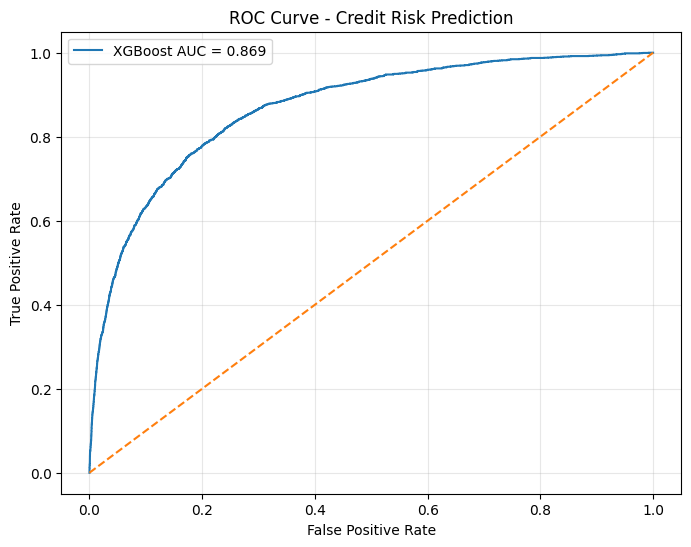


CUSTOMER RISK SEGMENTATION
Low Risk       28285
Medium Risk     1364
High Risk        351
Name: count, dtype: int64


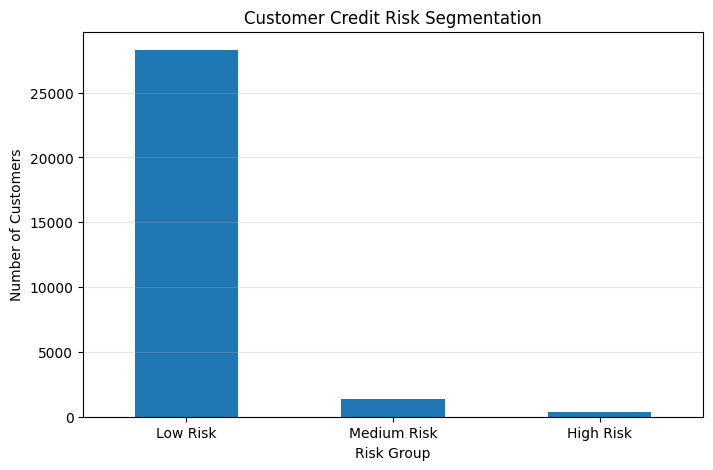

In [7]:
# ==========================================
# Q4 - STEP 3
# THRESHOLD + CONFUSION MATRIX + RISK GROUPS
# ==========================================

from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Select model with highest AUC
auc_scores = {
    'Logistic Regression': roc_auc_score(y_test, log_prob),
    'Random Forest': roc_auc_score(y_test, rf_prob),
    'XGBoost': roc_auc_score(y_test, xgb_prob)
}

print("MODEL AUC SCORES")
print("=" * 50)

for name, score in auc_scores.items():
    print(name, ":", round(score, 4))

best_name = max(auc_scores, key=auc_scores.get)

if best_name == 'Logistic Regression':
    best_prob = log_prob
elif best_name == 'Random Forest':
    best_prob = rf_prob
else:
    best_prob = xgb_prob

print("\nBest Model:", best_name)

# ------------------------------------------
# Threshold adjustment
# Lower threshold reduces false negatives
# ------------------------------------------

threshold = 0.30

risk_pred = (
    best_prob >= threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    risk_pred
)

tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)

print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nThreshold:", threshold)

print("Recall:",
      round(recall_score(y_test, risk_pred), 4))

print("Precision:",
      round(precision_score(
          y_test,
          risk_pred,
          zero_division=0
      ), 4))

# ------------------------------------------
# ROC Curve
# ------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'{best_name} AUC = {auc_scores[best_name]:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Risk Prediction')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------
# Customer risk segmentation
# ------------------------------------------

risk_score = best_prob

risk_group = np.where(
    risk_score >= 0.60,
    'High Risk',
    np.where(
        risk_score >= 0.30,
        'Medium Risk',
        'Low Risk'
    )
)

risk_summary = pd.Series(
    risk_group
).value_counts()

print("\n" + "=" * 50)
print("CUSTOMER RISK SEGMENTATION")
print("=" * 50)

print(risk_summary)

# Visualization
plt.figure(figsize=(8, 5))

risk_summary.plot(kind='bar')

plt.title('Customer Credit Risk Segmentation')
plt.xlabel('Risk Group')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

TOP CREDIT-RISK INDICATORS
NumberOfTimes90DaysLate                 0.395399
NumberOfTime60_89DaysPastDueNotWorse    0.195477
NumberOfTime30_59DaysPastDueNotWorse    0.149382
RevolvingUtilizationOfUnsecuredLines    0.145706
NumberRealEstateLoansOrLines            0.027411
age                                     0.021643
NumberOfOpenCreditLinesAndLoans         0.019092
DebtRatio                               0.016688
MonthlyIncome                           0.016335
NumberOfDependents                      0.012866
dtype: float32


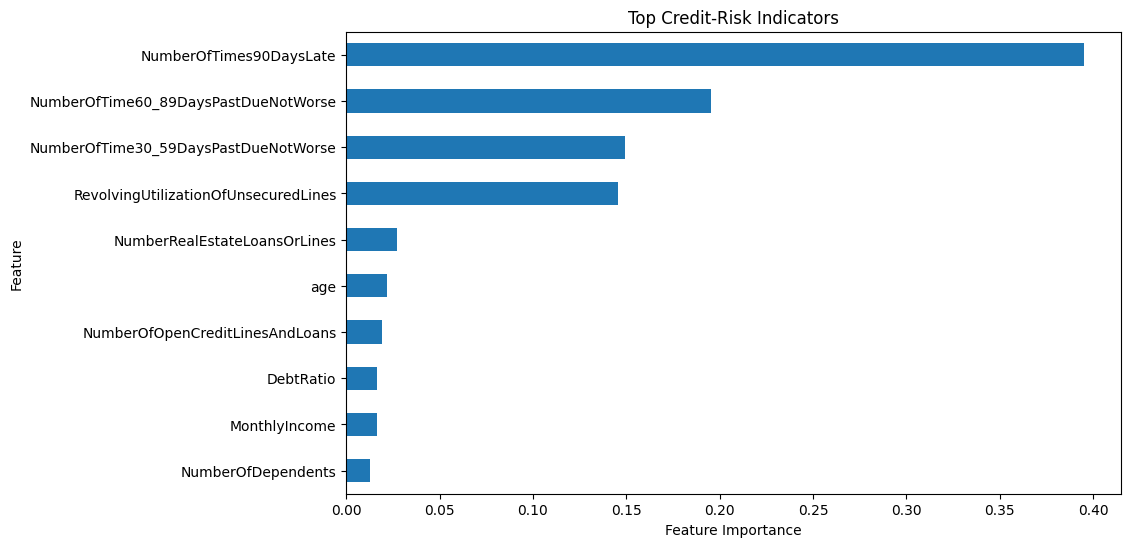


TOP 3 CREDIT-RISK INDICATORS
1. NumberOfTimes90DaysLate: 0.3954
2. NumberOfTime60_89DaysPastDueNotWorse: 0.1955
3. NumberOfTime30_59DaysPastDueNotWorse: 0.1494

CREDIT-RISK MANAGEMENT RECOMMENDATIONS

1. Income-Based Credit Limits:
   Customers with lower income and higher debt burden
   should receive conservative credit limits.

2. Early-Warning Alerts:
   Customers showing repeated late payments or high
   credit utilization should receive early-risk alerts.

3. High-Risk Monitoring:
   Customers classified as High Risk should receive
   closer monitoring and stricter approval conditions.

4. Threshold-Based Intervention:
   Use the lower prediction threshold to identify more
   potential defaulters early and reduce false negatives.



In [8]:
# ==========================================
# Q4 - STEP 4
# FEATURE IMPORTANCE + RECOMMENDATIONS
# ==========================================

# Feature importance from XGBoost
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("=" * 60)
print("TOP CREDIT-RISK INDICATORS")
print("=" * 60)

print(importance.head(10))

# Plot top 10
plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top Credit-Risk Indicators')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

print("\n" + "=" * 60)
print("TOP 3 CREDIT-RISK INDICATORS")
print("=" * 60)

for i, (feature, value) in enumerate(
    importance.head(3).items(),
    start=1
):
    print(f"{i}. {feature}: {value:.4f}")

print("\n" + "=" * 60)
print("CREDIT-RISK MANAGEMENT RECOMMENDATIONS")
print("=" * 60)

print("""
1. Income-Based Credit Limits:
   Customers with lower income and higher debt burden
   should receive conservative credit limits.

2. Early-Warning Alerts:
   Customers showing repeated late payments or high
   credit utilization should receive early-risk alerts.

3. High-Risk Monitoring:
   Customers classified as High Risk should receive
   closer monitoring and stricter approval conditions.

4. Threshold-Based Intervention:
   Use the lower prediction threshold to identify more
   potential defaulters early and reduce false negatives.
""")